In [ ]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_value_
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, hamming_loss
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import re
from html import unescape


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
EMBED_DIM = 300
HIDDEN1 = 200
HIDDEN2 = 100
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.01
DROP_PROB1 = 0.5
DROP_PROB2 = 0.5
CLIP_VALUE = 10.0
PATIENCE = 5
OPTIMIZER = "AdamW"

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/drive/My Drive/emotion-detection-fall-2025-nlp/train.csv')
test_df = pd.read_csv('/content/drive/My Drive/emotion-detection-fall-2025-nlp/test.csv')


In [ ]:
TEXT_COL = "Tweet"
ID_COL = "ID"

In [ ]:
if TEXT_COL not in train_df.columns:
    raise ValueError(f"Expected a '{TEXT_COL}' column in train.csv. Found columns: {train_df.columns.tolist()}")

In [ ]:
label_cols = [c for c in train_df.columns if c not in (TEXT_COL, ID_COL)]
print(f"Label columns ({len(label_cols)}): {label_cols}")

Label columns (11): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


In [ ]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = unescape(text)
    text = text.replace('\n', ' ')

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = text.replace('â€œ', '"').replace('â€™', "'").replace('ðŸ', '')

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
if TEXT_COL not in train_df.columns:
    raise ValueError(f"Expected a '{TEXT_COL}' column in train.csv. Found columns: {train_df.columns.tolist()}")


In [ ]:
train_df[TEXT_COL] = train_df[TEXT_COL].astype(str).apply(clean_tweet).str.lower()

test_df[TEXT_COL] = test_df[TEXT_COL].astype(str).apply(clean_tweet).str.lower()


In [ ]:
train_plus_val_texts, test_internal_texts, train_plus_val_labels, test_internal_labels = train_test_split(
    train_df[TEXT_COL].values,
    train_df[label_cols].values,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_plus_val_texts, train_plus_val_labels,
    test_size=0.17647058823529413,
    random_state=SEED,
    shuffle=True
)

In [ ]:
n_total = len(train_df)
print("Dataset sizes (from train.csv):", "train=", len(train_texts), "val=", len(val_texts), "test_internal=", len(test_internal_texts), "total=", n_total)

Dataset sizes (from train.csv): train= 5406 val= 1159 test_internal= 1159 total= 7724


In [ ]:
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for t in texts:
        counter.update(t.split())

    tokens = [tok for tok, cnt in counter.items() if cnt >= min_freq]

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, tok in enumerate(tokens, start=2):
        vocab[tok] = i
    return vocab

MIN_FREQ = 2
vocab = build_vocab(train_texts, min_freq=MIN_FREQ)
vocab_size = len(vocab)
print("Vocab size:", vocab_size)


Vocab size: 6351


In [ ]:
def encode_text(text, vocab):

    return [vocab.get(tok, vocab["<UNK>"]) for tok in text.split()]

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = [encode_text(t, vocab) for t in texts]
        self.labels = None if labels is None else np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        t = torch.tensor(self.texts[idx], dtype=torch.long)
        if self.labels is None:
            return t
        lbl = torch.tensor(self.labels[idx], dtype=torch.float32)
        return t, lbl

In [ ]:
def collate_train(batch):

    texts, labels = zip(*batch)
    lengths = [t.size(0) for t in texts]
    offsets = [0] + np.cumsum(lengths[:-1]).tolist()
    offsets = torch.tensor(offsets, dtype=torch.long)
    texts_cat = torch.cat(texts)
    labels = torch.stack(labels)
    return texts_cat, offsets, labels

def collate_test(batch):

    texts = batch
    lengths = [t.size(0) for t in texts]
    offsets = [0] + np.cumsum(lengths[:-1]).tolist()
    offsets = torch.tensor(offsets, dtype=torch.long)
    texts_cat = torch.cat(texts)
    return texts_cat, offsets

In [ ]:
train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)
test_internal_dataset = EmotionDataset(test_internal_texts, test_internal_labels)
kaggle_test_dataset = EmotionDataset(test_df[TEXT_COL].values, labels=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_train)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_train)
test_internal_loader = DataLoader(test_internal_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_train)
kaggle_test_loader = DataLoader(kaggle_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_test)

In [ ]:
class EmotionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden1, hidden2, output_dim, drop1=0.5, drop2=0.5):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, mode='mean', sparse=False)
        self.fc1 = nn.Linear(embed_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(drop1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(drop2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.out = nn.Linear(hidden2, output_dim)

    def forward(self, text, offsets):

        emb = self.embedding(text, offsets)  # shape: (batch_size, embed_dim)
        x = self.fc1(emb)
        x = self.relu1(x)
        x = self.drop1(x)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        x = self.bn2(x)
        logits = self.out(x)
        return logits


In [ ]:
output_dim = len(label_cols)
model = EmotionModel(vocab_size, EMBED_DIM, HIDDEN1, HIDDEN2, output_dim, DROP_PROB1, DROP_PROB2).to(DEVICE)
print(model)

EmotionModel(
  (embedding): EmbeddingBag(6351, 300, mode='mean')
  (fc1): Linear(in_features=300, out_features=200, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.5, inplace=False)
  (bn1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.5, inplace=False)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=100, out_features=11, bias=True)
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [ ]:
best_val_f1 = -1.0
best_epoch = -1
patience_counter = 0

train_losses = []
val_losses = []
val_f1s = []


In [ ]:
for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} - train", leave=False)
    for texts_cat, offsets, labels in pbar:
        texts_cat, offsets, labels = texts_cat.to(DEVICE), offsets.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(texts_cat, offsets)
        loss = criterion(logits, labels)
        loss.backward()
        clip_grad_value_(model.parameters(), CLIP_VALUE)
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_dataset)
    train_losses.append(avg_train_loss)


    model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for texts_cat, offsets, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} - val", leave=False):
            texts_cat, offsets, labels = texts_cat.to(DEVICE), offsets.to(DEVICE), labels.to(DEVICE)

            logits = model(texts_cat, offsets)
            loss = criterion(logits, labels)
            val_running_loss += loss.item() * labels.size(0)

            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu())
            all_trues.append(labels.cpu())

    avg_val_loss = val_running_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    all_preds = torch.vstack(all_preds).numpy()
    all_trues = torch.vstack(all_trues).numpy()


    pred_labels = (all_preds >= 0.5).astype(int)
    epoch_val_f1 = f1_score(all_trues, pred_labels, average='macro')

    if epoch_val_f1 > best_val_f1 + 1e-8:
        best_val_f1 = epoch_val_f1
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  -> New best model saved (Val F1 = {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break



Epoch 1/10 - train:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 1/10 - val:   0%|          | 0/10 [00:00<?, ?it/s]

  -> New best model saved (Val F1 = 0.0403)


Epoch 2/10 - train:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 2/10 - val:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 9/10 - val:   0%|          | 0/10 [00:00<?, ?it/s]

  -> New best model saved (Val F1 = 0.3672)


Epoch 10/10 - train:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 10/10 - val:   0%|          | 0/10 [00:00<?, ?it/s]

  -> New best model saved (Val F1 = 0.3930)


In [ ]:
print(f"Training finished. Best val F1={best_val_f1:.4f} at epoch {best_epoch}.")


Training finished. Best val F1=0.3930 at epoch 10.


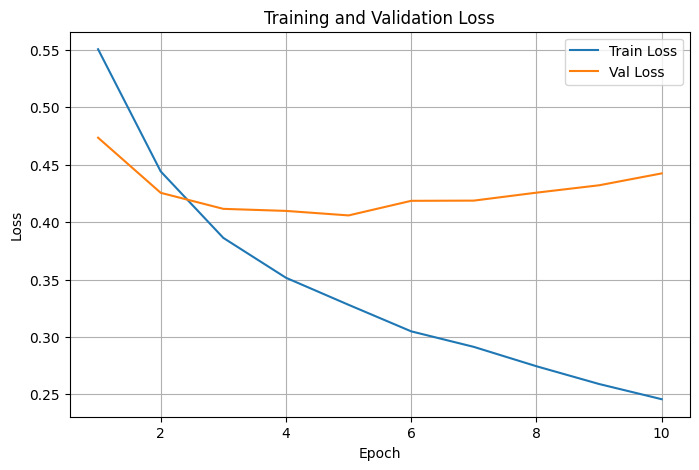

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

The X-axis represents the number of times the entire training dataset has passed through neural network.
The Y-axis represent the error of the model.
Both the training and validation loss decrease or are close indicating the model is learning useful patterns and generaliing well in the initial phases that is epochs 1 - 5.
Epoch 6 onwards the train loss continues to decrease,meaning the model is getting better,but the validation loss starts to increase which is a sign of **overfitting.**
The suggested recommendation would be to increase Dropout rates to probably 0.7.Increase weight decay to 0.05 0r 0.1.Decrease the learning rate to 0.005.

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))
model.to(DEVICE)
model.eval()

EmotionModel(
  (embedding): EmbeddingBag(6351, 300, mode='mean')
  (fc1): Linear(in_features=300, out_features=200, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.5, inplace=False)
  (bn1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.5, inplace=False)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=100, out_features=11, bias=True)
)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, hamming_loss

def evaluate_loader(loader, model, criterion, device):
    model.eval()
    all_preds = []
    all_trues = []
    running_loss = 0.0

    with torch.no_grad():
        for texts_cat, offsets, labels in loader:
            texts_cat, offsets, labels = texts_cat.to(device), offsets.to(device), labels.to(device)

            logits = model(texts_cat, offsets)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_trues.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_trues = np.vstack(all_trues)


    preds_binary = (all_preds >= 0.5).astype(int)

    avg_loss = running_loss / len(loader.dataset)
    macro_f1 = f1_score(all_trues, preds_binary, average='macro')
    h_loss = hamming_loss(all_trues, preds_binary)

    return avg_loss, macro_f1, h_loss, all_trues, preds_binary


In [ ]:
test_loss, test_f1, test_hamming, test_trues, test_preds = evaluate_loader(
    test_internal_loader, model, criterion, DEVICE
)

print(f"\nInternal test set evaluation -> Loss: {test_loss:.4f}, "
      f"Macro-F1: {test_f1:.4f}, Hamming Loss: {test_hamming:.4f}")


Internal test set evaluation -> Loss: 0.4509, Macro-F1: 0.3877, Hamming Loss: 0.1773


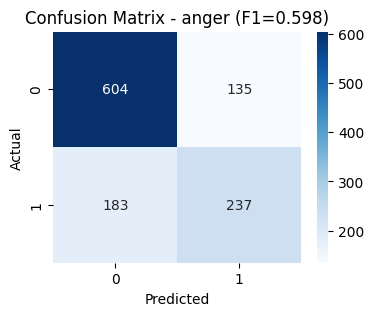

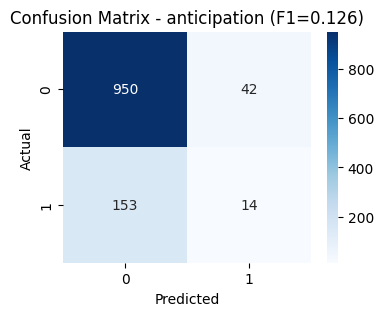

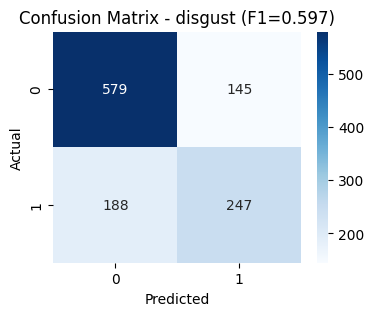

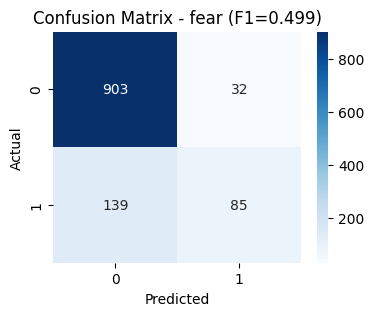

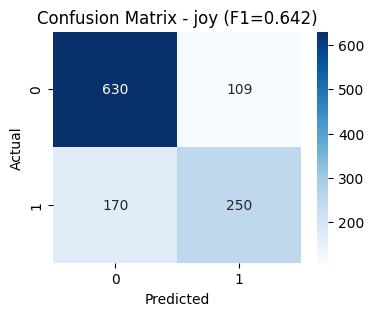

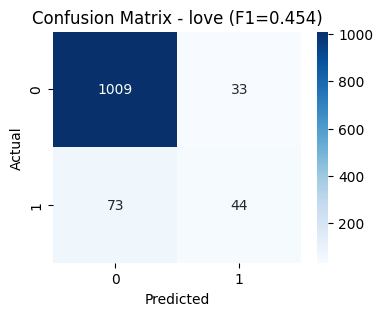

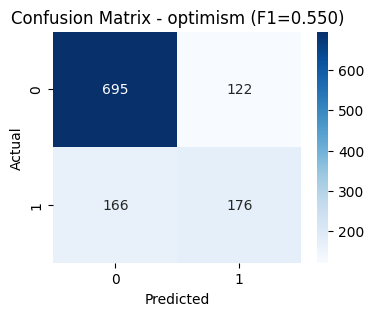

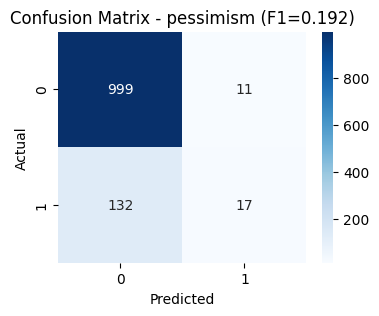

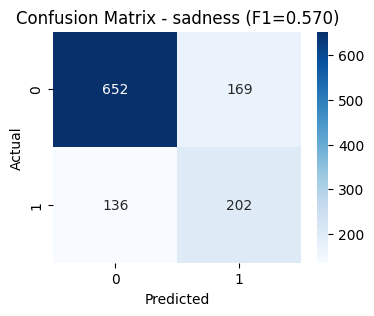

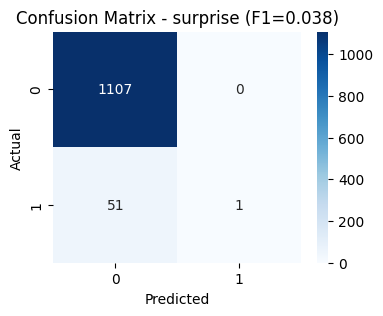

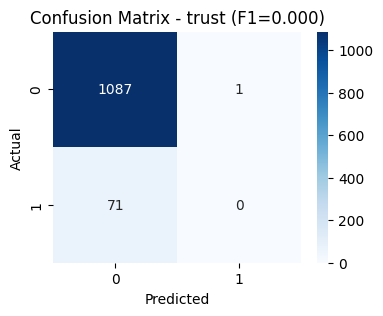

In [ ]:
per_label_f1 = []
num_labels = len(label_cols)
for i, label_name in enumerate(label_cols):
    cm = confusion_matrix(test_trues[:, i], test_preds[:, i])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    lbl_f1 = f1_score(test_trues[:, i], test_preds[:, i], average='binary', zero_division=0)
    per_label_f1.append(lbl_f1)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {label_name} (F1={lbl_f1:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
for name, f in zip(label_cols, per_label_f1):
    print(f"{name}: F1 = {f:.4f}")

anger: F1 = 0.5985
anticipation: F1 = 0.1256
disgust: F1 = 0.5973
fear: F1 = 0.4985
joy: F1 = 0.6418
love: F1 = 0.4536
optimism: F1 = 0.5500
pessimism: F1 = 0.1921
sadness: F1 = 0.5698
surprise: F1 = 0.0377
trust: F1 = 0.0000


Based on the F1 scores secured we can tell that emotions such as joy(0.6418) , anger(0.5985),disgust(0.5973)and sadness(0.5698) are the most accurately predicted emotions.
Emotions like trust(0.000),anticipation(0.1256),surprise(0.0377) and pessimism(0.1921)have very low scores suggesting the model often misclassifies these emotions.
There appears to be a bias toward emotions with more distinct or stronger signals in the text such as joy,anger and fear ,while more subtle or nuanced emotions like trust ,anticipation and surprise are under predicted.This could be due to class imbalance or overlapping textual features between certain emotions.



In [ ]:
model.eval()
preds_list = []
with torch.no_grad():
    for texts_cat, offsets in tqdm(kaggle_test_loader, desc="Kaggle inference"):
        texts_cat = texts_cat.to(DEVICE)
        offsets = offsets.to(DEVICE)
        logits = model(texts_cat, offsets)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds_binary = (probs >= 0.5).astype(int)
        preds_list.append(preds_binary)

preds_list = np.vstack(preds_list)
submission = pd.DataFrame(preds_list, columns=label_cols)
submission.insert(0, ID_COL, test_df[ID_COL].values)
submission.to_csv("submission.csv", index=False)
print("\nKaggle submission saved to submission.csv")
print(submission.head())

Kaggle inference:   0%|          | 0/26 [00:00<?, ?it/s]


Kaggle submission saved to submission.csv
           ID  anger  anticipation  disgust  fear  joy  love  optimism  \
0  2018-01559      0             1        0     1    0     0         0   
1  2018-03739      1             0        1     0    0     0         0   
2  2018-00385      0             0        0     0    1     0         1   
3  2018-03001      0             0        0     0    0     0         0   
4  2018-01988      0             0        0     0    0     0         0   

   pessimism  sadness  surprise  trust  
0          0        0         0      0  
1          0        0         0      0  
2          0        0         0      0  
3          0        1         0      0  
4          0        1         0      0  


In [ ]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>